## Decision Tree Hyperparameter Tuning
This notebook demonstrates:

Loading a dataset
Training a baseline Decision Tree
Understanding hyperparameters
GridSearchCV hyperparameter tuning
Evaluating the tuned model
Visualizing the final tree
Dataset: Breast Cancer (built into scikit-learn)

In [1]:
# Import libraries

import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

In [2]:
# Load dataset

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

X.head()

Shape of X: (569, 30)
Shape of y: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])


Training records: 455
Testing records: 114


### Baseline Decision Tree

In [4]:
baseline_model = DecisionTreeClassifier(random_state=42)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.9473684210526315


### Important Hyperparameters
max_depth
min_samples_split
min_samples_leaf
criterion

In [7]:
param = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7 ,8,10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print(param)


{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, 7, 8, 10], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}


## GridSearchCV
Grid Search tries every combination of parameters and selects the best one.

In [8]:
dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


results_df = pd.DataFrame(grid_search.cv_results_)


results_df.to_csv("gridsearch_results.csv", index=False)

print("CSV file saved successfully!")

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)


CSV file saved successfully!
Best Parameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}

Best Cross Validation Score:
0.9472527472527472


In [9]:
from sklearn.model_selection import RandomizedSearchCV


# Create Decision Tree Model
dt = DecisionTreeClassifier(random_state=42)

# Random Search
random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param,   # Same parameter dictionary used in GridSearchCV
    n_iter=50,                   # Number of random combinations to try
    cv=5,                        # 5-Fold Cross Validation
    scoring='accuracy',          # Evaluation metric
    random_state=42,             # Ensures reproducibility
    n_jobs=-1                    # Use all CPU cores
)

# Train the model
random_search.fit(X_train, y_train)

# Convert CV results to DataFrame
results_df = pd.DataFrame(random_search.cv_results_)

# Save results to CSV
results_df.to_csv("randomsearch_results.csv", index=False)

print("CSV file saved successfully!")

# Best Parameters
print("Best Parameters:")
print(random_search.best_params_)

# Best Cross Validation Score
print("\nBest Cross Validation Score:")
print(random_search.best_score_)

CSV file saved successfully!
Best Parameters:
{'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 7, 'criterion': 'entropy'}

Best Cross Validation Score:
0.9472527472527472


In [10]:
best_model = grid_search.best_estimator_

print(best_model)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=10,
                       random_state=42)


In [11]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Tuned Model Accuracy:", accuracy)


Tuned Model Accuracy: 0.956140350877193


In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [13]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[39  4]
 [ 1 70]]


In [14]:
print("Baseline Accuracy :", baseline_accuracy)
print("Tuned Accuracy    :", accuracy)


Baseline Accuracy : 0.9473684210526315
Tuned Accuracy    : 0.956140350877193


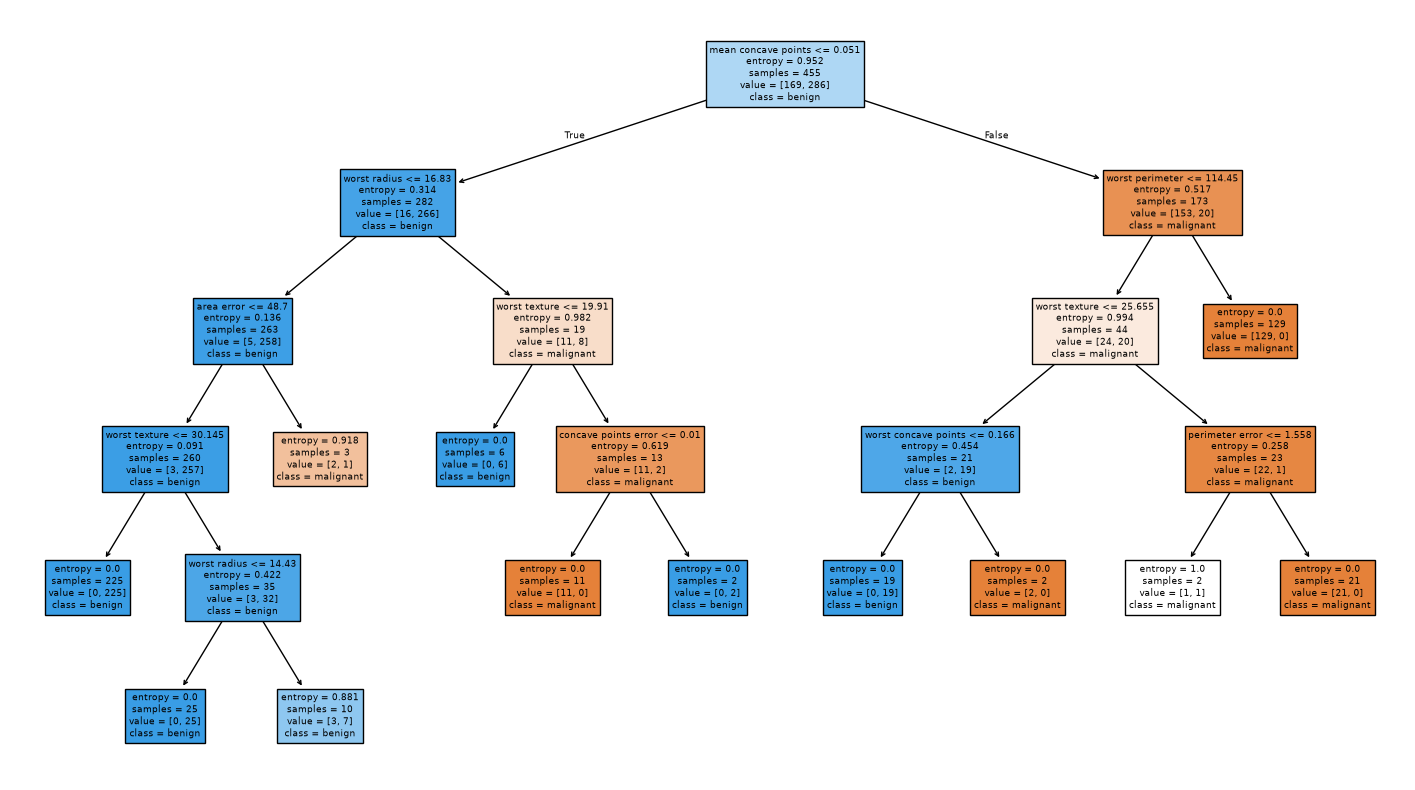

In [15]:
plt.figure(figsize=(18,10))

plot_tree(
    best_model,
    filled=True,
    max_depth=5,
    feature_names=data.feature_names,
    class_names=data.target_names
)

plt.show()

### Summary
Hyperparameter tuning helps improve performance by finding the best:

criterion
max_depth
min_samples_split
min_samples_leaf
splitter
GridSearchCV automates this search using cross validation.